# Total Rainfall

Historical analysis of daily and accumulated precipitation at the selected GHCN station. Covers annual totals, reference-period anomalies, seasonal splits and ENSO modulation (ONI).

**Indicator:** annual accumulated rainfall normalised to 365 days, expressed relative to the WMO 1961–1990 reference period.



```{glue:figure} accum_rain
:scale: 60%
:align: center
```

**Figure. Annual total rainfall anomalies relative to 1961–1990 climatology at Koror.** Units are mm/year.  The colored dots represent the 10 warmest years on record, with the absolute values shown along the right axis.    The dashed black line represents a trend that is not statistically significant.

## Setup

Import libraries and helper functions. Shared plotting utilities come from the [indicators_setup](https://github.com/lauracagigal/indicators_setup) repository; site configuration and output helpers come from `functions/rainfall.py`.


In [1]:
import warnings

warnings.filterwarnings("ignore")
import os.path as op
import sys
from pathlib import Path

from myst_nb import glue

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../../../../indicators_setup")
from ind_setup.plotting_int import plot_timeseries_interactive
from ind_setup.plotting import plot_bar_probs
from ind_setup.core import fontsize

sys.path.append("../../functions")
from data_downloaders import download_oni_index
from rainfall import (
    load_site_config,
    site_config_filename,
    build_site_figures_dir,
    build_output_filename,
    persist_total_rainfall_outputs,
)
from ind_setup.plotting_int import plot_oni_index_th
from ind_setup.plotting import plot_bar_probs_ONI, add_oni_cat


### Define location and variables of interest

Set `site_key` to match the site name used in `00_site_setup.ipynb` (e.g. `"Palau"`). The notebook loads coordinates, station ID, reference period and paths from `data/sites/<site_key>.json`.


### Get Data

Load the cached daily `PRCP` series from `data/rainfall/GHCN_<station_id>.pkl`. All download and quality-control steps were completed in `00_site_setup.ipynb`.


In [2]:
site_key = "Palau"

site_config_path = Path("../../data/sites") / site_config_filename(site_key)
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get("site_name", "Site")
site_lon = float(site_cfg["site_lon"])
site_lat = float(site_cfg["site_lat"])
country = site_cfg["country"]
ghcn_station_id = site_cfg["ghcn_station_id"]
ghcn_station_name = site_cfg.get("ghcn_station_name", "")
vars_interest = list(site_cfg.get("vars_interest", ["PRCP"]))
ref_start = str(site_cfg.get("reference_period_start", "1961"))
ref_end = str(site_cfg.get("reference_period_end", "1990"))

In [3]:
data_base_dir = Path("../../data")
site_figures_dir = build_site_figures_dir(Path("../../outputs"), site_name, site_lon, site_lat)
data_dir = Path(data_base_dir, "rainfall")

data_dir.mkdir(parents=True, exist_ok=True)
path_data = str(data_dir)


### Observations from Station

Daily precipitation records for the GHCN station defined in the site configuration.


[GHCN-Daily documentation](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/doc/GHCND_documentation.pdf)


The data used for this analysis comes from the [GHCN-Daily](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/) database (NOAA NCEI).

GHCN-Daily provides historical daily precipitation records over global land areas. Records from numerous sources are merged and subjected to quality-assurance reviews. The variable used here is **`PRCP`** (daily precipitation total, mm).

**Data loading:** this notebook reads the pre-processed pickle created by `00_site_setup.ipynb`. It does **not** re-download from NOAA.

**Outputs:** figures → `outputs/figures/<site_tag>/`; tables and JSON → `outputs/tables/<site_tag>/`.


In [4]:
pickle_path = data_dir / f"GHCN_{ghcn_station_id}.pkl"
data = pd.read_pickle(pickle_path)
print(f"Loaded {len(data)} daily records from {pickle_path}")
data_daily = data.copy()


Loaded 26652 daily records from ../../data/rainfall/GHCN_PSW00040309.pkl


## Analysis

All indicators below are computed from the loaded daily `PRCP` series. Linear trends are estimated with `plot_bar_probs` / `plot_timeseries_interactive` from `indicators_setup`.


### Daily and annual precipitation


#### Daily precipitation time series

Interactive plot of raw daily `PRCP` with a fitted trend line. Saved as `F5_Rain_daily_<site_tag>.html`.


In [5]:
dict_prcp = [{"data": data, "var": "PRCP", "ax": 1, "label": "Daily precipitation"}]
fig, trend_da_mean = plot_timeseries_interactive(
    dict_prcp,
    trendline=True,
    figsize=(25, 12),
    label_yaxes="Precipitation [mm]",
    return_trend=True,
)
fig.write_html(
    site_figures_dir / build_output_filename("F5_Rain_daily", site_name, site_lon, site_lat, ext="html"),
)


#### Annual daily maxima

The wettest day recorded in each calendar year. Highlights changes in extreme daily rainfall.


Annual maximum daily precipitation with a fitted trend. Saved as `F5_Rain_annual_max_<site_tag>.html`.


In [6]:
data_max = data.groupby(data.index.year).max()
data_max.index = pd.to_datetime(data_max.index, format="%Y")

dict_plot = [
    {"data": data_max, "var": "PRCP", "ax": 1, "label": "Annual daily maxima"},
]
fig_max = plot_timeseries_interactive(
    dict_plot, trendline=True, figsize=(25, 12), label_yaxes="Precipitation [mm]"
)
fig_max.write_html(
    site_figures_dir / build_output_filename("F5_Rain_annual_max", site_name, site_lon, site_lat, ext="html"),
)


#### Accumulated precipitation

Annual accumulated rainfall normalised for observation count:

$$	ext{annual total} = rac{\sum 	ext{PRCP}}{	ext{days observed}} 	imes 365$$

This allows fair comparison between years with different data coverage.


Bar chart of normalised annual accumulated precipitation with linear trend. Saved as `F5_Rain_accum_<site_tag>.png`.


In [7]:
# Correct accumulated precipitation with number of observations per year to make fair comparisons and trends
datag = (
    data.groupby(data.index.year).sum() / data.groupby(data.index.year).count()
) * 365
datag.index = pd.to_datetime(datag.index, format="%Y")
dict_plot = [
    {"data": datag, "var": "PRCP", "ax": 1, "label": "Accumulated precipitation [mm]"},
]



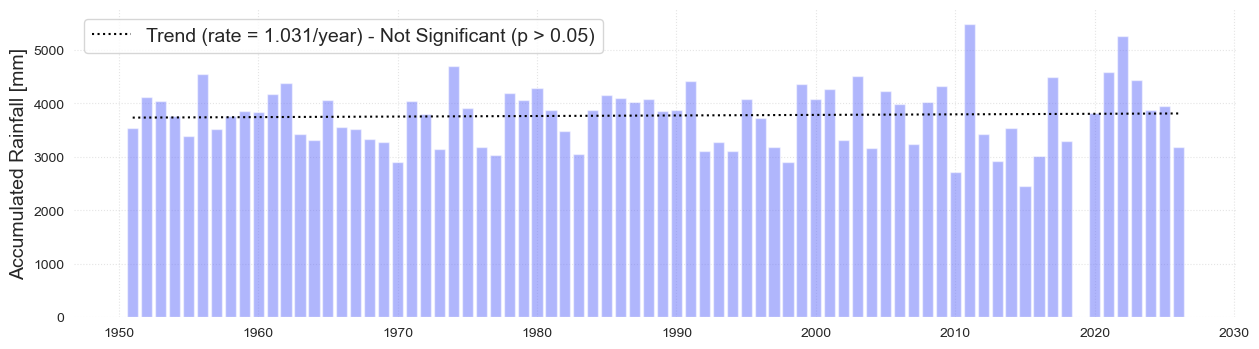

In [8]:
fig, ax, trend_ac_an = plot_bar_probs(
    x=datag.index.year,
    y=datag["PRCP"].values,
    trendline=True,
    figsize=[15, 4],
    return_trend=True,
)
ax.set_ylabel("Accumulated Rainfall [mm]", fontsize=fontsize)
plt.savefig(
    site_figures_dir / build_output_filename("F5_Rain_accum", site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches="tight",
)
glue("accum_rain", fig, display=False)


In [9]:
datag

,PRCP
DATE,
1951-01-01,3532.366848
1952-01-01,4112.034153
1953-01-01,4044.300000
1954-01-01,3753.400000
1955-01-01,3388.900000
...,...
2022-01-01,5255.102459
2023-01-01,4433.240602
2024-01-01,3881.546875


In [10]:
nevents = 10  # Top n events to extract
datag["PRCP_ref"] = datag["PRCP"].values - datag.loc[ref_start:ref_end].PRCP.mean()
top_10 = datag.sort_values(by="PRCP_ref", ascending=False).head(nevents)




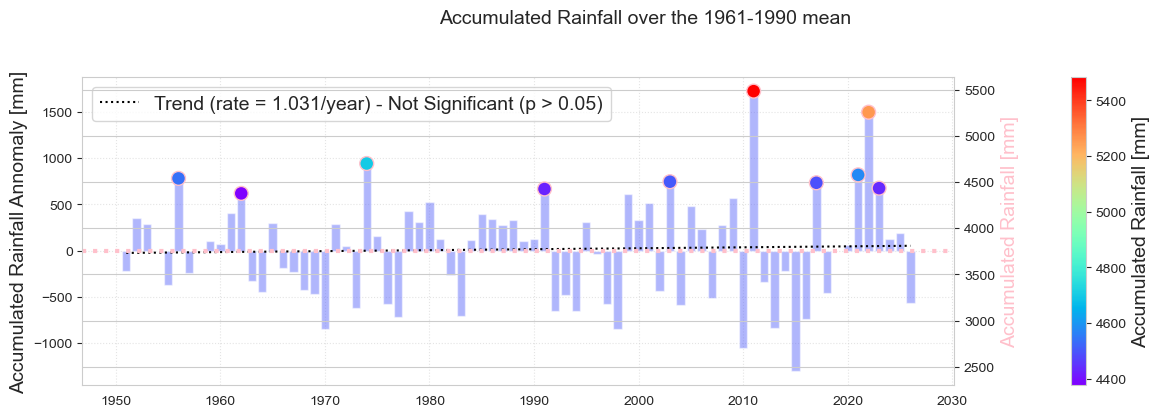

In [11]:
prcp_an = datag["PRCP"].values - datag.loc[ref_start:ref_end].PRCP.mean()
fig, ax = plot_bar_probs(x=datag.index.year, y=prcp_an, trendline=True, figsize=[15, 4])
ax.set_ylim(np.nanmin(prcp_an) - 150, np.nanmax(prcp_an) + 150)
ax.set_ylabel("Accumulated Rainfall Annomaly [mm]", fontsize=fontsize)
ax2 = ax.twinx()
ax2.axhline(
    datag.loc[ref_start:ref_end].PRCP.mean(), color="pink", linestyle=":", linewidth=3
)
ax2.set_ylim(
    np.nanmin(prcp_an) - 150 + datag.loc[ref_start:ref_end].PRCP.mean(),
    np.nanmax(prcp_an) + 150 + datag.loc[ref_start:ref_end].PRCP.mean(),
)
ax2.set_ylabel("Accumulated Rainfall [mm]", fontsize=fontsize, color="pink")

im = ax2.scatter(
    top_10.index.year,
    top_10.PRCP,
    c=top_10.PRCP.values,
    s=100,
    ec="pink",
    cmap="rainbow",
    label="Top 10 warmest years",
)

plt.colorbar(im, pad=0.1).set_label("Accumulated Rainfall [mm]", fontsize=fontsize)
fig.suptitle("Accumulated Rainfall over the 1961-1990 mean", fontsize=fontsize, y=1.05)
plt.savefig(
    site_figures_dir / build_output_filename("F5_Rain_anom_top10", site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches="tight",
)
glue("accum_rain", fig, display=False)


### Seasonal accumulated rainfall

Annual accumulated rainfall split by season. The Palau convention used here:

- **Dry season:** November–April (months 11, 12, 1–4)
- **Wet season:** May–October (months 5–10)

Adjust the month boundaries if applying this notebook to a site with a different seasonal cycle.


#### Dry season (November–April)

Accumulated rainfall anomaly relative to the 1961–1990 dry-season mean. Saved as `F6a_Rain_dry_season_<site_tag>.png`.


#### Wet season (May–October)

Accumulated rainfall anomaly relative to the 1961–1990 wet-season mean. Saved as `F6a_Rain_wet_season_<site_tag>.png`.


In [12]:
data.loc[(data.index.month >= 5) & (data.index.month < 11), "season"] = "wet"
data.loc[(data.index.month < 5) | (data.index.month >= 11), "season"] = "dry"



In [49]:
data_dry = data.loc[data.season == "dry"].drop("season", axis=1)
datag_dry = (
    data_dry.groupby(data_dry.index.year).sum()
    / data_dry.groupby(data_dry.index.year).count()
) * 365/2
datag_dry.index = pd.to_datetime(datag_dry.index, format="%Y")



In [50]:
print('Mean:\n',datag_dry.loc[ref_start:ref_end].PRCP.mean())
print('Maximum:\n', datag_dry.loc[datag_dry.PRCP.idxmax()]- datag_dry.loc[ref_start:ref_end].PRCP.mean())
print('Minimum:\n', datag_dry.loc[datag_dry.PRCP.idxmin()]- datag_dry.loc[ref_start:ref_end].PRCP.mean())

Mean:
 1534.5746825228177
Maximum:
 PRCP    898.321726
Name: 1974-01-01 00:00:00, dtype: float64
Minimum:
 PRCP   -745.388218
Name: 1983-01-01 00:00:00, dtype: float64


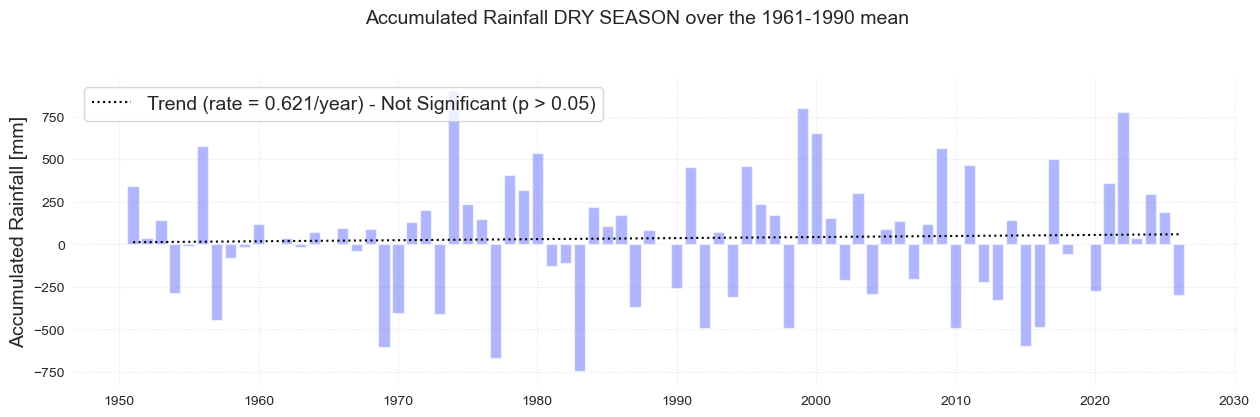

In [51]:
fig, ax = plot_bar_probs(
    x=datag_dry.index.year,
    y=datag_dry["PRCP"].values - datag_dry.loc[ref_start:ref_end].PRCP.mean(),
    trendline=True,
    figsize=[15, 4],
)
ax.set_ylabel("Accumulated Rainfall [mm]", fontsize=fontsize)
fig.suptitle(
    "Accumulated Rainfall DRY SEASON over the 1961-1990 mean", fontsize=fontsize, y=1.05
)
plt.savefig(
    site_figures_dir / build_output_filename("F6a_Rain_dry_season", site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches="tight",
)


In [55]:
data_wet = data.loc[data.season == "wet"].drop("season", axis=1)
datag_wet = (
    data_wet.groupby(data_wet.index.year).sum()
    / data_wet.groupby(data_wet.index.year).count()
) * 365/2
datag_wet.index = pd.to_datetime(datag_wet.index, format="%Y")



In [56]:
print('Mean:\n',datag_wet.loc[ref_start:ref_end].PRCP.mean())
print('Maximum:\n', datag_wet.loc[datag_wet.PRCP.idxmax()]- datag_wet.loc[ref_start:ref_end].PRCP.mean())
print('Minimum:\n', datag_wet.loc[datag_wet.PRCP.idxmin()]- datag_wet.loc[ref_start:ref_end].PRCP.mean())

Mean:
 2217.315489130435
Maximum:
 PRCP    1255.044565
Name: 2011-01-01 00:00:00, dtype: float64
Minimum:
 PRCP   -744.719022
Name: 1997-01-01 00:00:00, dtype: float64


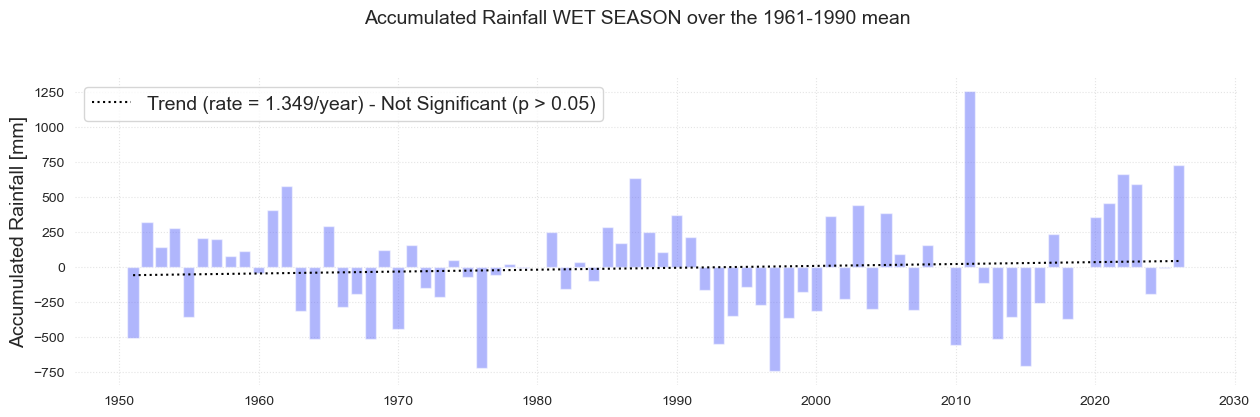

In [57]:
fig, ax = plot_bar_probs(
    x=datag_wet.index.year,
    y=datag_wet["PRCP"].values - datag_wet.loc[ref_start:ref_end].PRCP.mean(),
    trendline=True,
    figsize=[15, 4],
)
ax.set_ylabel("Accumulated Rainfall [mm]", fontsize=fontsize)
fig.suptitle(
    "Accumulated Rainfall WET SEASON over the 1961-1990 mean", fontsize=fontsize, y=1.05
)
plt.savefig(
    site_figures_dir / build_output_filename("F6a_Rain_wet_season", site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches="tight",
)


## ENSO analysis (ONI index)


The [Oceanic Niño Index (ONI)](https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php) monitors El Niño and La Niña events based on sea-surface temperature anomalies in the Niño 3.4 region (3-month running mean).

Monthly precipitation is joined with ONI to assess how ENSO phases modulate rainfall at the station. El Niño years are coloured red, La Niña blue, Neutral grey.


In [64]:
p_data = "https://psl.noaa.gov/data/correlation/oni.data"

In [20]:
update_oni = True
if update_oni:
    df1 = download_oni_index(p_data)
    df1.to_pickle(op.join(path_data, "oni_index.pkl"))
else:
    df1 = pd.read_pickle(op.join(path_data, "oni_index.pkl"))



In [21]:
lims = [-0.5, 0.5]
plot_oni_index_th(df1, lims=lims)



### ENSO-modulated precipitation anomalies

Annual mean daily and accumulated precipitation anomalies, coloured by ONI category.


In [22]:
st_data = data_daily
st_data_monthly = st_data.resample("ME").mean()
st_data_monthly.index = pd.DatetimeIndex(st_data_monthly.index).to_period(
    "M"
).to_timestamp() #+ pd.offsets.MonthBegin(1)



In [23]:
df1["prcp"] = st_data_monthly["PRCP"]  # .rolling(window=rolling_mean).mean()



In [24]:
df1 = add_oni_cat(df1, lims=lims)



ONI-coloured bar plots saved as `F5_Rain_mean_ONI_daily_<site_tag>.png` and `F5_Rain_mean_ONI_accum_<site_tag>.png`.


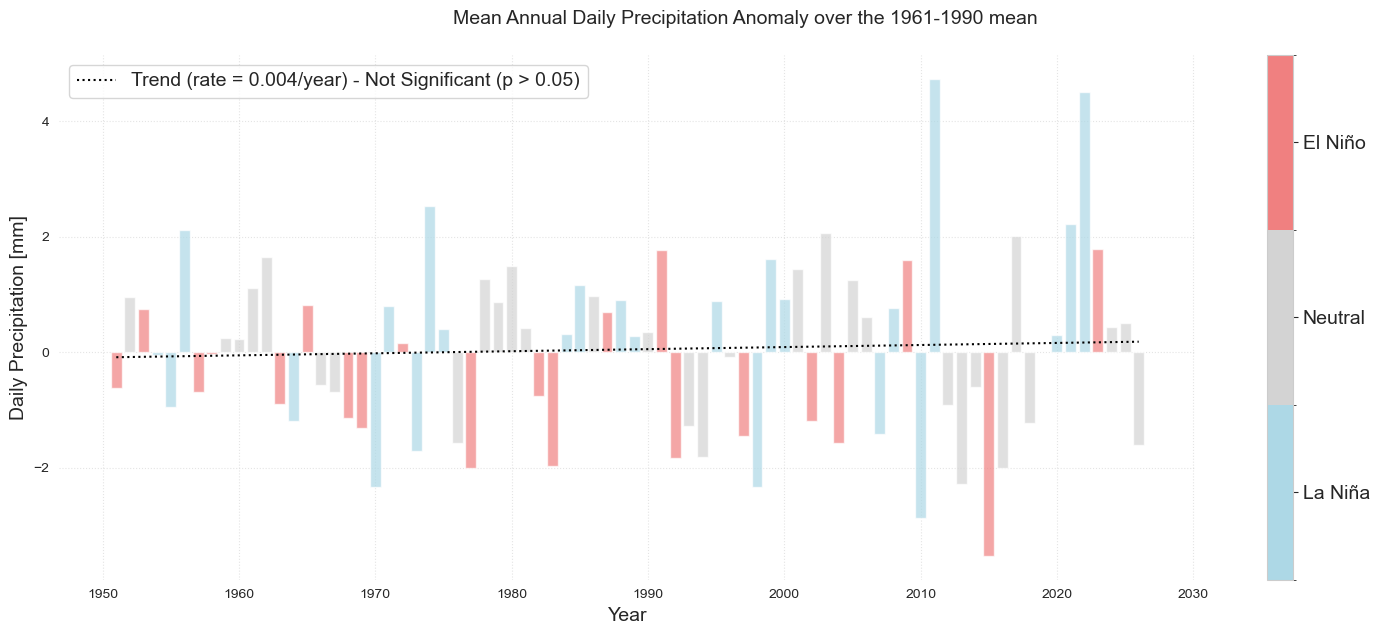

In [25]:
df2 = df1.resample("YE").mean()
df2["prcp_ref"] = df2.prcp - df2.loc[ref_start:ref_end].prcp.mean()
fig = plot_bar_probs_ONI(df2, var="prcp_ref", y_label="Daily Precipitation [mm]")
fig.suptitle(
    "Mean Annual Daily Precipitation Anomaly over the 1961-1990 mean",
    fontsize=fontsize,
    y=1.05,
)
plt.savefig(
    site_figures_dir / build_output_filename("F5_Rain_mean_ONI_daily", site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches="tight",
)


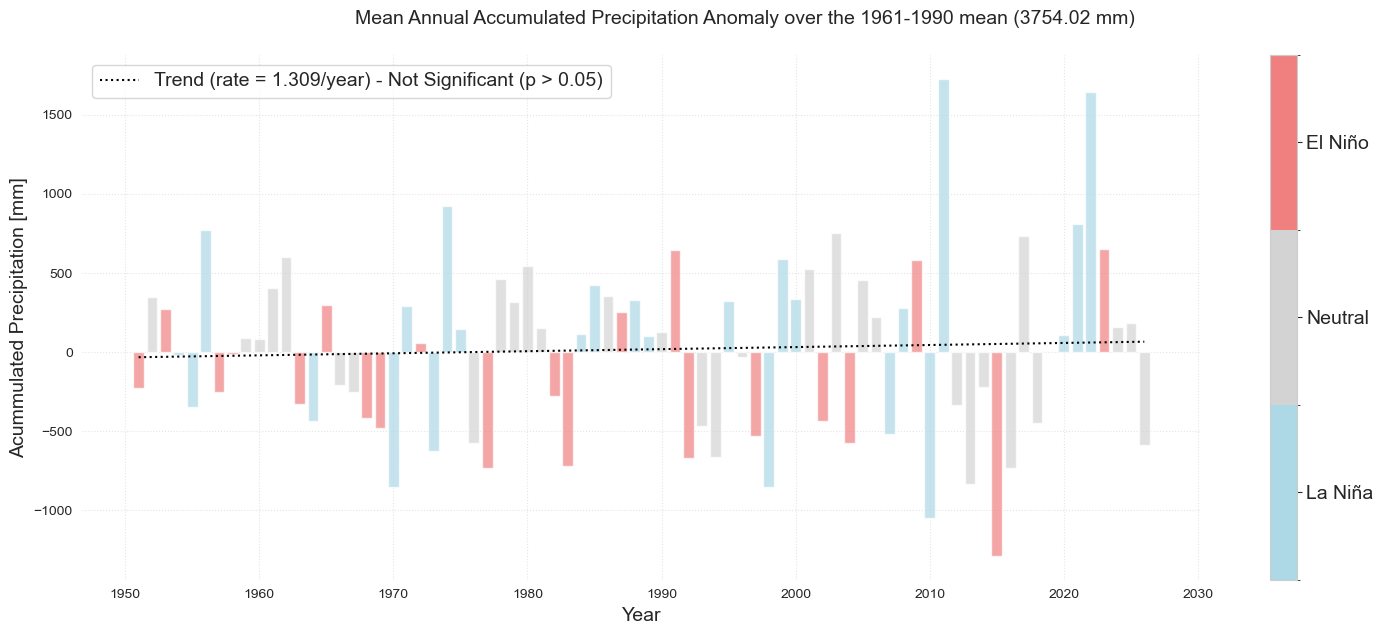

In [26]:
df3 = df1.resample("YE").mean()
df3['prcp'] = df1['prcp'].resample("YE").mean()*365.25
df3["prcp_ref"] = df3.prcp - df3.loc[ref_start:ref_end].prcp.mean()
fig = plot_bar_probs_ONI(df3, var="prcp_ref", y_label="Acummulated Precipitation [mm]")
fig.suptitle(
    f"Mean Annual Accumulated Precipitation Anomaly over the 1961-1990 mean ({df3.loc[ref_start:ref_end].prcp.mean():.2f} mm)",
    fontsize=fontsize,
    y=1.05,
)
plt.savefig(
    site_figures_dir / build_output_filename("F5_Rain_mean_ONI_accum", site_name, site_lon, site_lat),
    dpi=300,
    bbox_inches="tight",
)


### Summary table and persisted outputs

The final cell builds the summary table (`table_rain_21`) and calls `persist_total_rainfall_outputs()` to save:

- `R_mean_annual_<site_tag>.csv`
- `R_mean_summary_table_<site_tag>.csv`
- `R_top10_wettest_years_<site_tag>.csv`
- `R_dry_season_annual_<site_tag>.csv` / `R_wet_season_annual_<site_tag>.csv`
- `R_ONI_annual_<site_tag>.csv`
- `R_mean_summary_metrics_<site_tag>.json`


In [27]:
from ind_setup.tables import table_rain_21

mean_ref = datag.loc[ref_start:ref_end].PRCP.mean()
summary_table = table_rain_21(data, df3, trend_da_mean, trend_ac_an)
persist_total_rainfall_outputs(
    Path("../../outputs"),
    site_name, site_lon, site_lat,
    ghcn_station_id, ghcn_station_name, country,
    datag, datag_dry, datag_wet, top_10, summary_table,
    trend_da_mean, trend_ac_an, mean_ref, ref_start, ref_end,
    df_oni=df3,
)


Metric,Value
Daily Precipitation Mean (mm),10.323
Daily Precipitation Max (mm) (1991),350.000
Change in Daily Precipitation since 1951 (mm),54.750
Rate of Change in Daily Precipitation (mm/year),0.002
,
Mean Accumulated Annual Precipitation (mm),3770.600
Maximum Accumulated Annual Precipitation (mm) (2011),5483.100
Minimum Accumulated Annual Precipitation (mm) (2015),2450.200
Change in Accumulated Annual Precipitation since 1951 (mm),77.325
Rate of Change in Accumulated Annual Precipitation (mm/year),1.031


PosixPath('../../outputs/tables/palau_lat7p337_lon134p477')